# Football Player Statistics — Multivariate Analysis
**YSU Multivariate Statistics — Final Project 2026**  
**Dataset:** Premier League 2023-24 player statistics (Fantasy Premier League)  
**Response variable:** `total_points`  

---
## Project Steps
1. Load & inspect the dataset
2. Describe the dataset
3. Scatterplot matrix
4. Gaussian distribution assessment
5. Choose the response variable
6. Linear regression (full model)
7. Variable selection (backward elimination via VIF + p-values)
8. PCA — fit & interpret
9. Correlation circle
10. PCA projection (coloured by position — Bonus)


In [1]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), '..'))

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110

print('Libraries loaded.')

Libraries loaded.


---
## Step 1 — Load the data

In [2]:
from src.load_data import load_data

df = load_data()
print(f'Shape: {df.shape}')
df.head(10)

Loading existing data from  /home/edgar/football_project/data/players.csv
  487 players  ×  19 columns
Shape: (487, 19)


,player,position,team,minutes,goals,assists,clean_sheets,yellow_cards,red_cards,bonus,xg,xa,xgi,influence,creativity,threat,ict_index,total_points,value
0,Fábio Ferreira Vieira,MID,1,290,1,3,1,0,1,0,1.25,0.64,1.89,82.8,88.8,85.0,25.5,24,4.4
1,Gabriel dos Santos Magalhães,DEF,1,3042,3,1,16,4,0,8,4.48,0.65,5.13,675.8,121.9,379.0,117.9,149,27.6
2,Kai Havertz,MID,1,2627,13,10,16,11,0,15,12.36,3.88,16.23,763.2,613.4,1027.0,240.2,180,23.7
3,Gabriel Fernando de Jesus,FWD,1,1470,4,7,11,6,0,10,6.27,3.26,9.53,364.8,403.0,756.0,152.7,85,11.0
4,Jorge Luiz Frello Filho,MID,1,913,0,2,4,1,0,1,0.10,1.77,1.87,165.4,187.8,16.0,36.8,44,8.3
5,Jakub Kiwior,DEF,1,942,1,3,6,1,0,1,0.74,0.60,1.34,228.8,106.9,90.0,42.7,67,16.8
6,Gabriel Martinelli Silva,MID,1,2010,6,5,10,1,0,6,6.36,5.18,11.53,500.4,717.1,795.0,200.8,118,15.7
7,Eddie Nketiah,FWD,1,1065,5,4,6,3,0,5,4.65,0.53,5.18,235.0,136.3,417.0,77.2,71,14.2
8,Martin Ødegaard,MID,1,3098,8,11,19,2,0,26,7.53,10.16,17.69,910.4,1499.4,757.0,317.0,186,21.6
9,Thomas Partey,MID,1,785,0,0,5,3,0,0,0.43,0.58,1.01,117.6,122.9,37.0,27.8,24,5.0


---
## Step 2 — Describe the dataset

In [3]:
from src.eda import describe_dataset, FEATURES

describe_dataset(df)

DATASET DESCRIPTION
  Rows (players)  : 487
  Columns         : 19
  Season          : Premier League 2023-24
  Source          : Fantasy Premier League (public GitHub)

── Position breakdown ───────────────────────────────────
position
MID    217
DEF    174
FWD     58
GK      38

── Numeric summary (core features) ─────────────────────
                  n     mean     std   min     25%      50%      75%      max
goals         487.0     2.45    3.83   0.0    0.00     1.00     3.00    27.00
assists       487.0     2.19    2.98   0.0    0.00     1.00     3.00    18.00
xg            487.0     2.45    3.57   0.0    0.32     1.13     3.01    29.57
xa            487.0     1.54    1.86   0.0    0.30     0.90     2.01    10.90
influence     487.0   365.33  269.04   6.4  142.70   323.00   530.60  1240.20
creativity    487.0   248.47  277.53   0.0   56.70   152.10   347.00  1674.90
threat        487.0   232.26  278.64   0.0   42.50   130.00   324.50  1581.00
ict_index     487.0    84.57   70.17 

In [5]:
# Numeric summary of ALL features used in the analysis
all_features = ['goals','assists','xg','xa','influence','creativity',
                'threat','ict_index','minutes','yellow_cards','clean_sheets']
df[all_features].describe().round(2)

,goals,assists,xg,xa,influence,creativity,threat,ict_index,minutes,yellow_cards,clean_sheets
count,487.00,487.00,487.00,487.00,487.00,487.00,487.00,487.00,487.00,487.00,487.00
mean,2.45,2.19,2.45,1.54,365.33,248.47,232.26,84.57,1533.01,3.24,3.91
std,3.83,2.98,3.57,1.86,269.04,277.53,278.64,70.17,945.13,2.77,3.70
min,0.00,0.00,0.00,0.00,6.40,0.00,0.00,1.60,90.00,0.00,0.00
25%,0.00,0.00,0.32,0.30,142.70,56.70,42.50,31.60,740.00,1.00,1.00
50%,1.00,1.00,1.13,0.90,323.00,152.10,130.00,66.10,1429.00,2.00,3.00
75%,3.00,3.00,3.01,2.01,530.60,347.00,324.50,117.50,2305.00,5.00,6.00
max,27.00,18.00,29.57,10.90,1240.20,1674.90,1581.00,375.70,3420.00,13.00,19.00


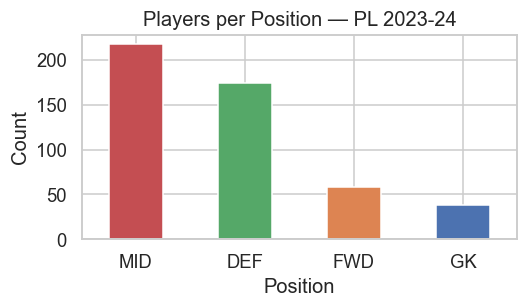

In [6]:
# Position distribution
fig, ax = plt.subplots(figsize=(5, 3))
df['position'].value_counts().plot.bar(ax=ax, color=['#c44e52','#55a868','#dd8452','#4c72b0'],
                                        edgecolor='white')
ax.set_title('Players per Position — PL 2023-24', fontweight='bold')
ax.set_xlabel('Position'); ax.set_ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

---
## Step 3 — Scatterplot matrix

We plot all 11 candidate features to visually inspect pairwise relationships and spot multicollinearity.

Saved → /home/edgar/football_project/figures/correlation_heatmap.png


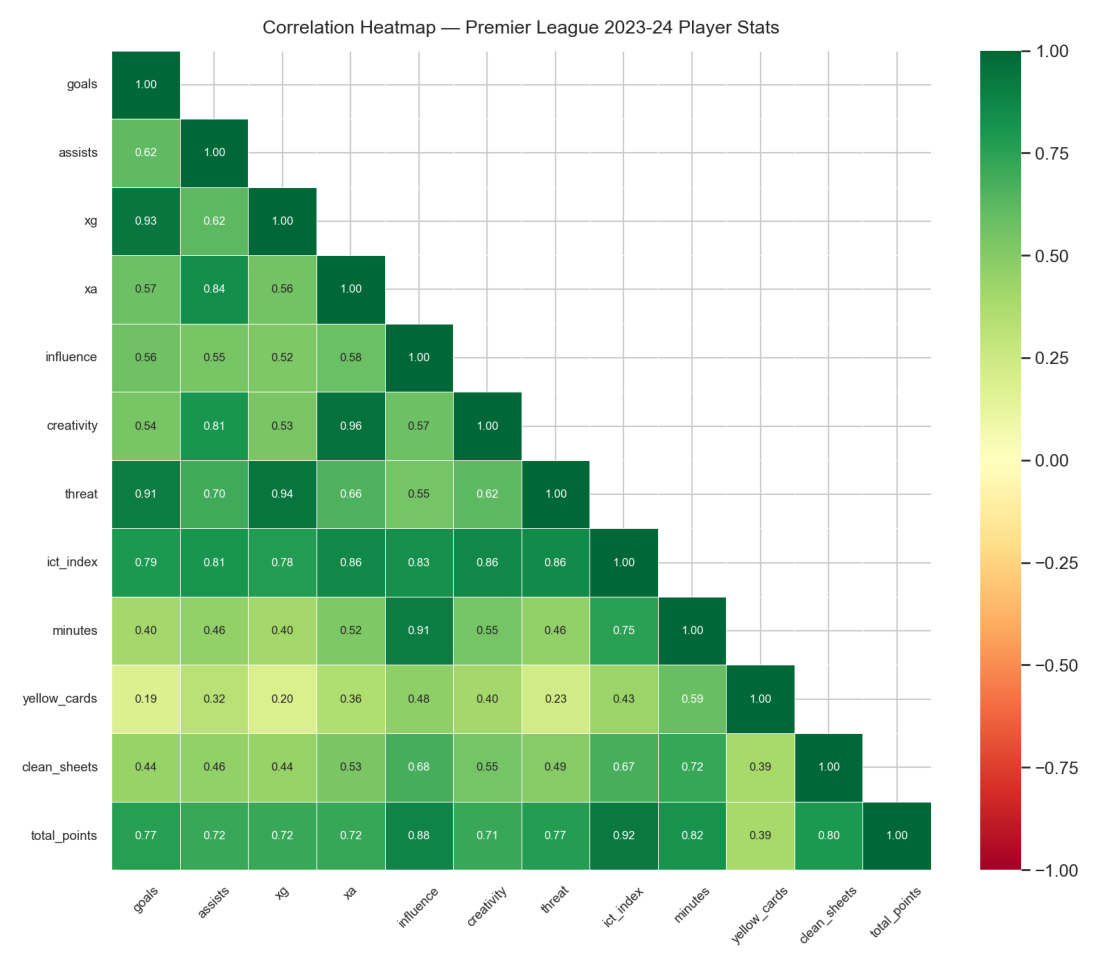

Saved → /home/edgar/football_project/figures/pairplot_scoring.png
Saved → /home/edgar/football_project/figures/pairplot_performance.png
Saved → /home/edgar/football_project/figures/pairplot_involvement.png


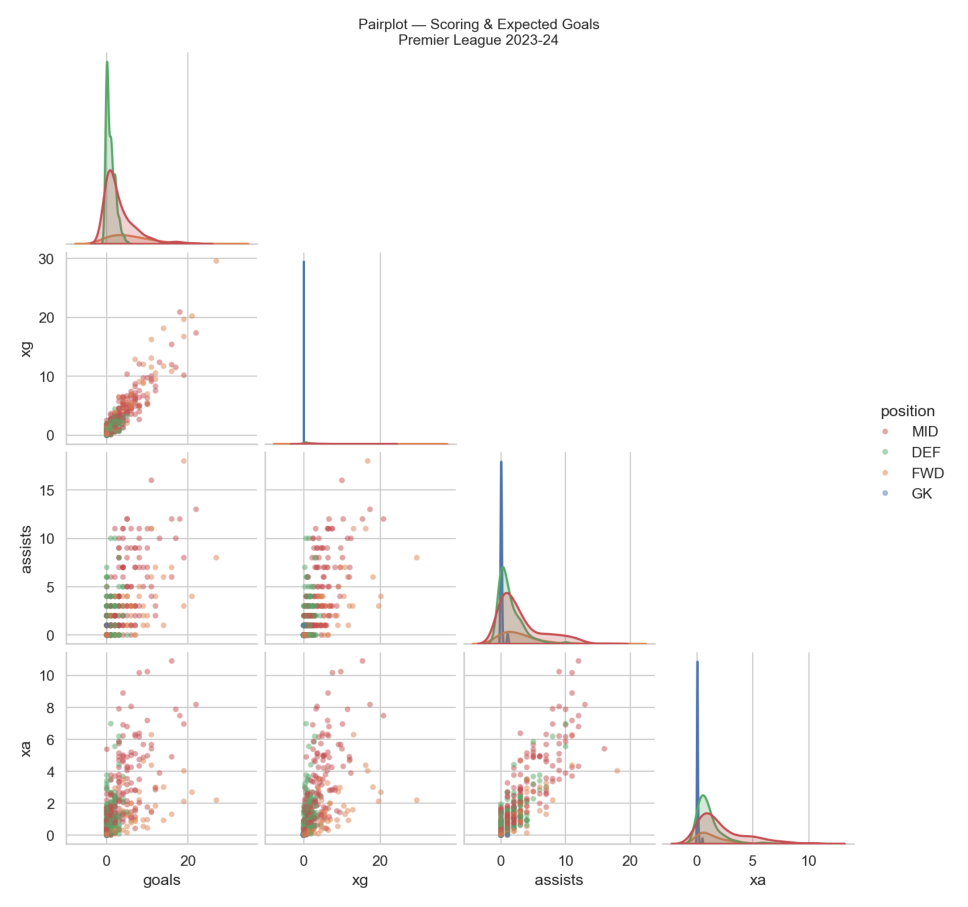

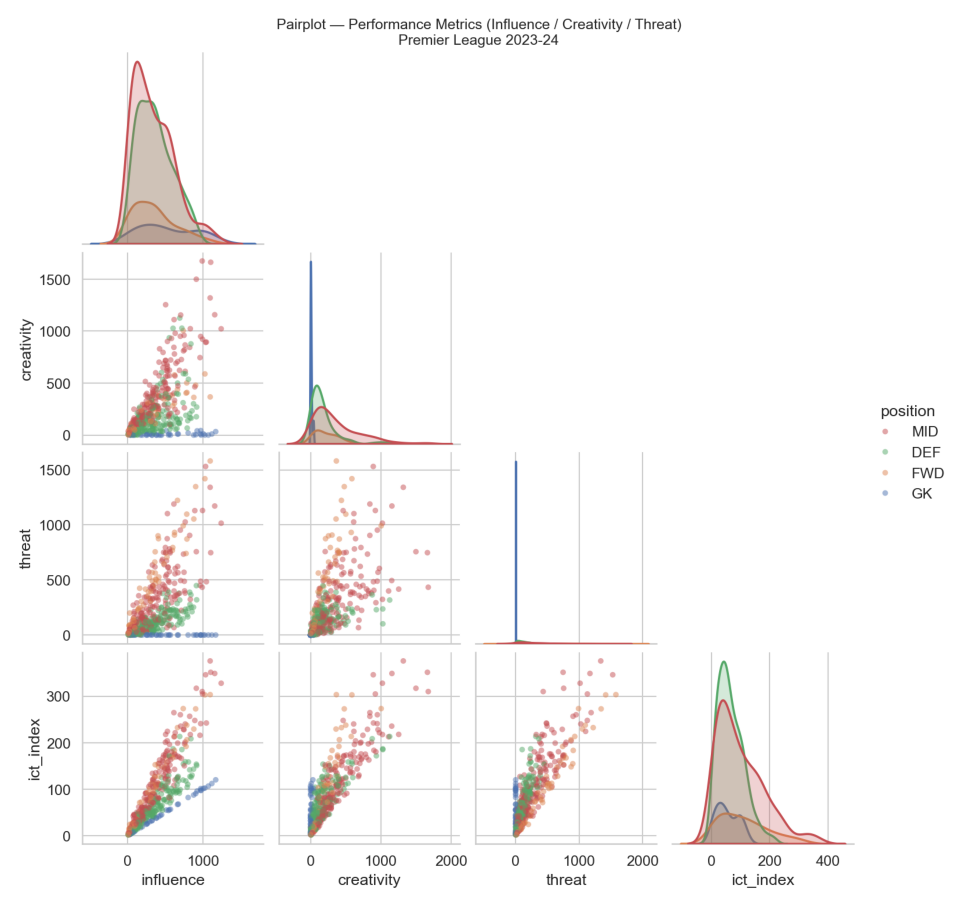

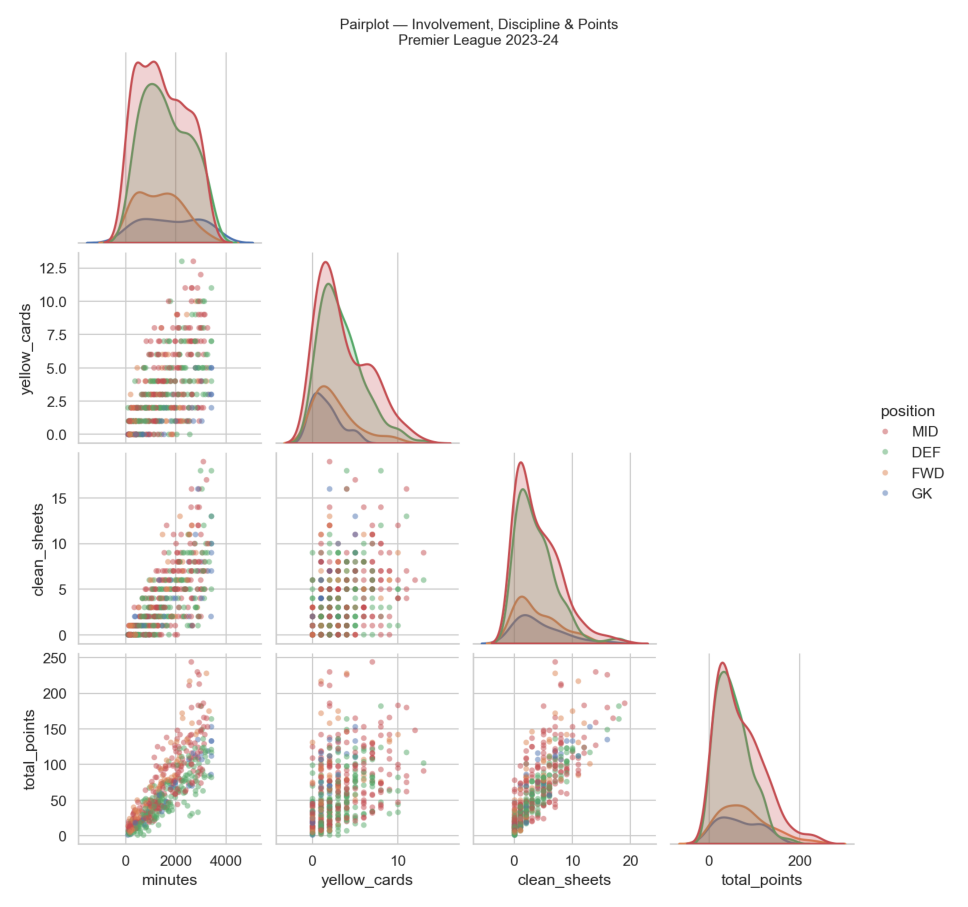

In [7]:
from src.eda import plot_grouped_pairplots, plot_correlation_heatmap

# ── Correlation heatmap — compact overview of all pairwise correlations ──
heatmap_path = plot_correlation_heatmap(df)
img = mpimg.imread(heatmap_path)
fig, ax = plt.subplots(figsize=(11, 9))
ax.imshow(img); ax.axis('off')
plt.tight_layout(); plt.show()

# ── 3 separate grouped pairplots — each group is small and readable ──
pairplot_paths = plot_grouped_pairplots(df)
for path in pairplot_paths:
    img = mpimg.imread(path)
    fig, ax = plt.subplots(figsize=(9, 9))
    ax.imshow(img); ax.axis('off')
    plt.tight_layout(); plt.show()

**Observations:**
- Strong positive correlations: `goals↔xg`, `assists↔xa`, `influence↔creativity↔threat↔ict_index`
- `ict_index` is a linear combination of `influence + creativity + threat` → severe multicollinearity
- Most distributions are right-skewed (many players score/assist rarely)

---
## Step 4 — Gaussian distribution assessment


── Normality Summary (Shapiro-Wilk) ────────────────────
Feature                  Skewness   Kurtosis    p-value   Normal?
-----------------------------------------------------------------
goals                       2.669      8.827     0.0000        no
assists                     1.940      3.983     0.0000        no
xg                          2.993     12.367     0.0000        no
xa                          2.025      4.497     0.0000        no
influence                   0.808      0.072     0.0000        no
creativity                  1.974      4.609     0.0000        no
threat                      2.004      4.404     0.0000        no
ict_index                   1.362      1.953     0.0000        no
minutes                     0.247     -1.084     0.0000        no
yellow_cards                0.998      0.457     0.0000        no
clean_sheets                1.206      1.503     0.0000        no

Saved → /home/edgar/football_project/figures/distributions.png


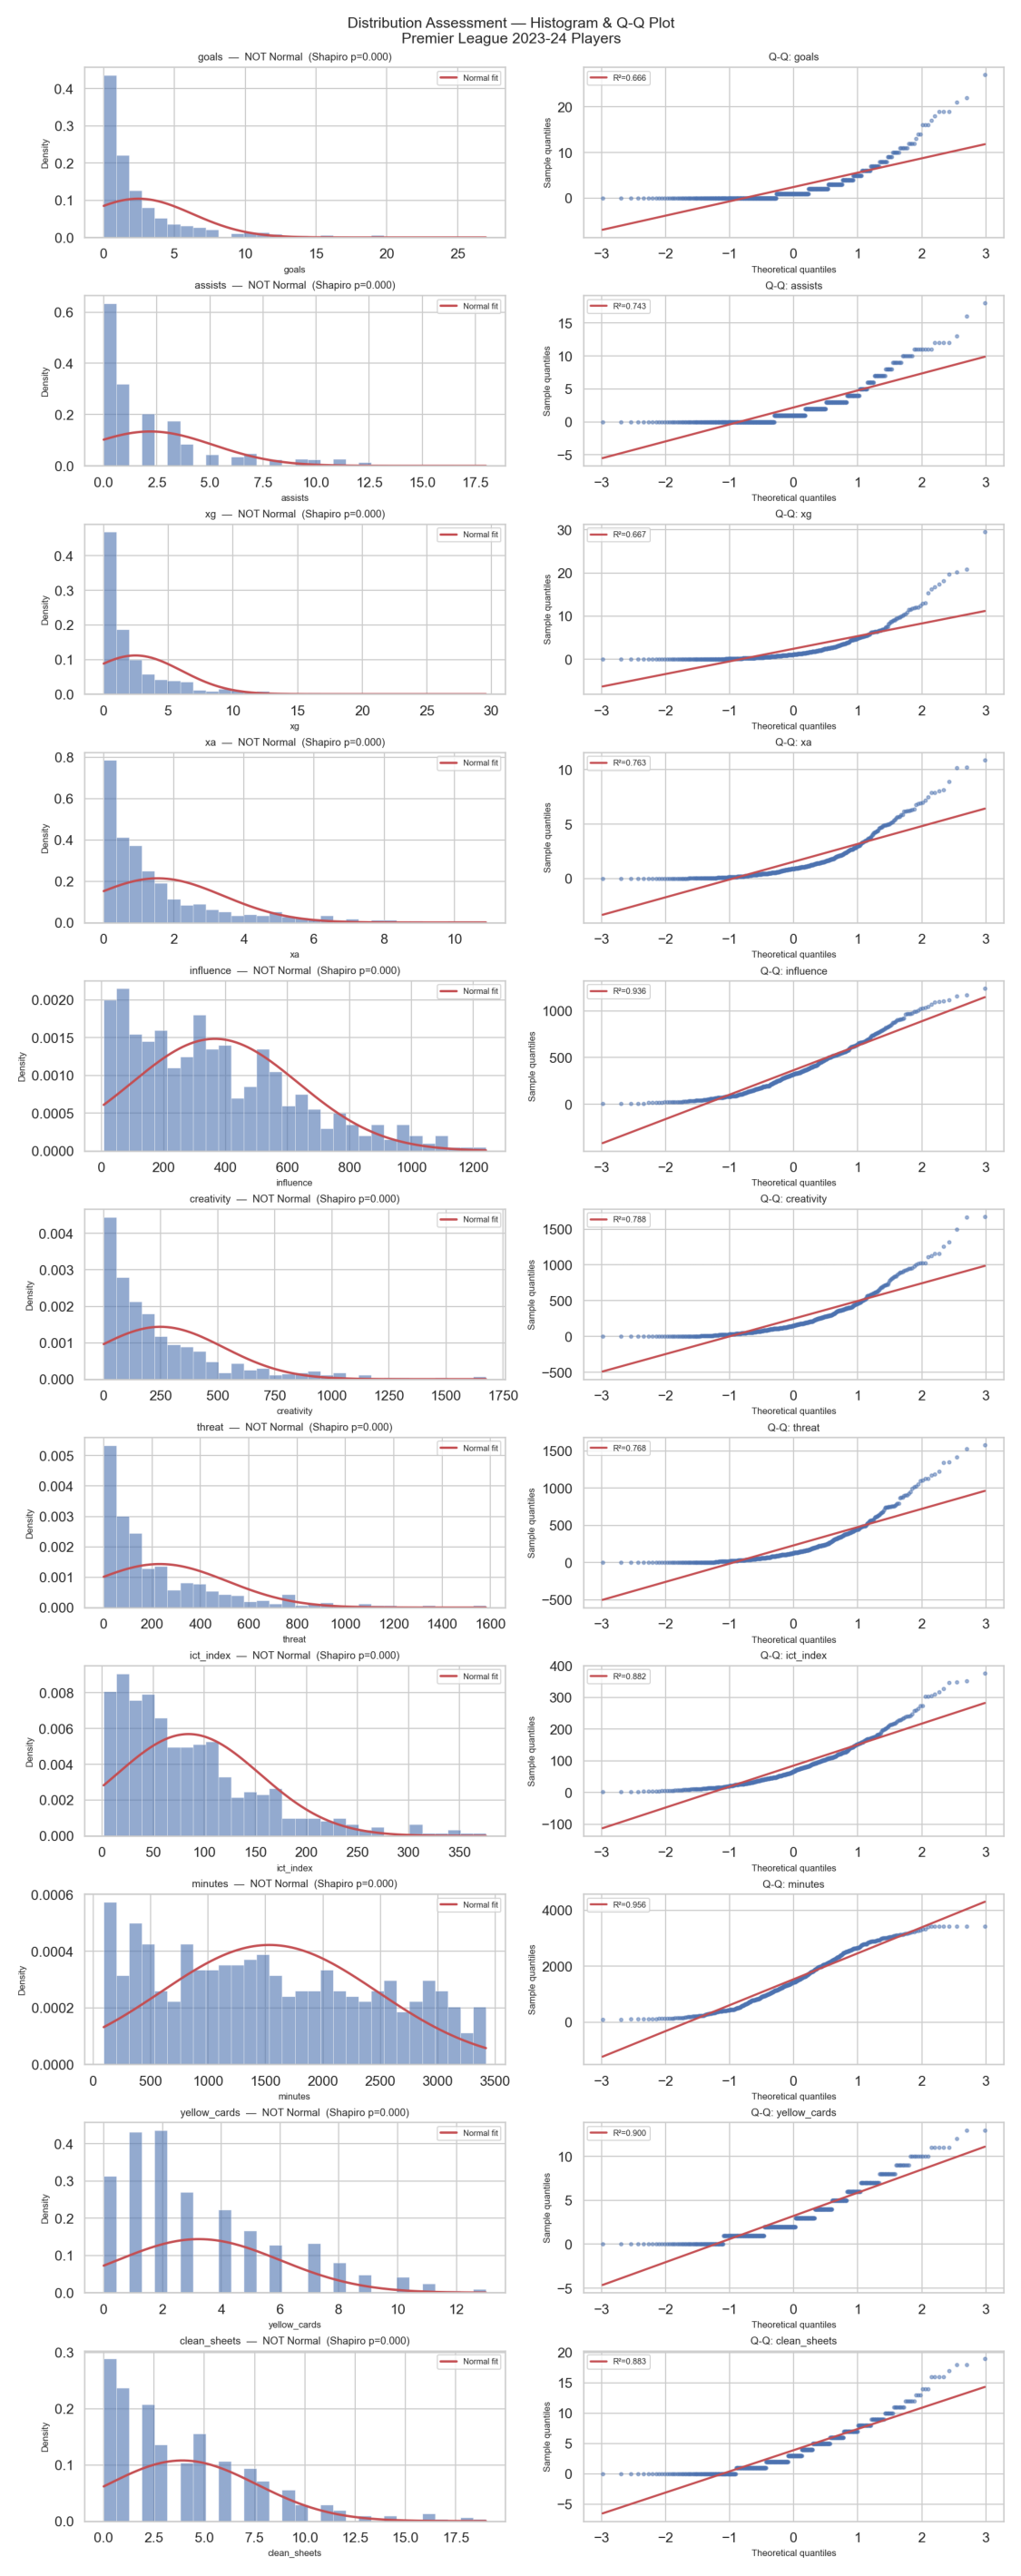

In [10]:
from src.eda import plot_distributions, print_gaussian_summary

print_gaussian_summary(df)

fig_path = plot_distributions(df)
img = mpimg.imread(fig_path)
fig, ax = plt.subplots(figsize=(12, 26))
ax.imshow(img); ax.axis('off')
plt.tight_layout()
plt.show()

**Observations:**
- **None** of the variables pass the Shapiro-Wilk normality test (all p ≈ 0)
- `goals`, `assists`, `xg`, `xa` are heavily **right-skewed** — most players score rarely, a few score a lot
- `minutes` is the closest to symmetric (skewness = 0.25) but still non-Gaussian
- Despite non-Gaussianity, linear regression and PCA remain valid as exploratory tools

---
## Step 5 — Response variable justification

We choose **`total_points`** (Fantasy Premier League points) as the response variable.

**Justification:**
- It is a well-defined numeric score assigned by a major professional organisation (Premier League / FPL)
- It aggregates real match outcomes: goals (6/5 pts), assists (3 pts), clean sheets, yellow/red cards, bonus points
- It is directly interpretable as a player's overall value/contribution in a season
- Predicting `total_points` from performance metrics tests whether observed stats can explain overall worth

---
## Step 6 — Full linear regression model

In [11]:
from src.regression import fit_full_model, ALL_FEATURES, RESPONSE

full_model = fit_full_model(df)

STEP 6 — FULL LINEAR REGRESSION MODEL
  Response : total_points
  Predictors: ['goals', 'assists', 'xg', 'xa', 'influence', 'creativity', 'threat', 'ict_index', 'minutes', 'yellow_cards', 'clean_sheets']
                            OLS Regression Results                            
Dep. Variable:           total_points   R-squared:                       0.966
Model:                            OLS   Adj. R-squared:                  0.966
Method:                 Least Squares   F-statistic:                     1243.
Date:                Wed, 03 Jun 2026   Prob (F-statistic):               0.00
Time:                        01:41:38   Log-Likelihood:                -1735.4
No. Observations:                 487   AIC:                             3495.
Df Residuals:                     475   BIC:                             3545.
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
      

**Observations from the full model:**
- R² = 0.966 — extremely high, but inflated by multicollinearity
- VIF of `ict_index` ≈ 78,000; `influence`, `creativity`, `threat` each ≈ 12,000 → severe collinearity
- Several coefficients have unexpected signs (`xg` is negative even though more expected goals should increase points) — a classic sign of multicollinearity
- The condition number (7,750) confirms numerical instability

---
## Step 7 — Variable selection (backward elimination)

In [12]:
from src.regression import variable_selection, fit_final_model, \
    plot_regression_diagnostics, plot_coefficients

selected_features, _ = variable_selection(df)

STEP 7 — BACKWARD VARIABLE SELECTION
  Step 1: Drop 'ict_index'  (VIF = 78185.8 > 10.0)
  Step 2: Drop 'xa'  (VIF = 15.6 > 10.0)
  Step 3: Drop 'xg'  (VIF = 12.4 > 10.0)
  Step 4: Drop 'minutes'  (VIF = 10.6 > 10.0)
  Step 5: Drop 'threat'  (p = 0.7201 > 0.05)

  Final features (6): ['goals', 'assists', 'influence', 'creativity', 'yellow_cards', 'clean_sheets']



In [13]:
final_model = fit_final_model(df, selected_features)

FINAL REGRESSION MODEL
                            OLS Regression Results                            
Dep. Variable:           total_points   R-squared:                       0.958
Model:                            OLS   Adj. R-squared:                  0.957
Method:                 Least Squares   F-statistic:                     1808.
Date:                Wed, 03 Jun 2026   Prob (F-statistic):               0.00
Time:                        01:45:11   Log-Likelihood:                -1792.1
No. Observations:                 487   AIC:                             3598.
Df Residuals:                     480   BIC:                             3628.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const            8.8079  

Saved → /home/edgar/football_project/figures/regression_coefficients.png


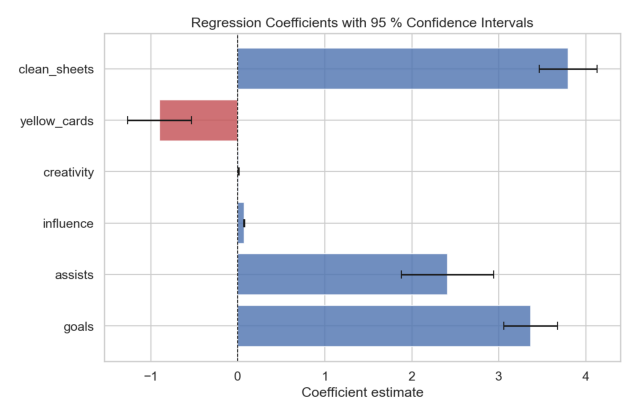

In [14]:
# Coefficient plot
fig_path = plot_coefficients(final_model)
img = mpimg.imread(fig_path)
fig, ax = plt.subplots(figsize=(8, 4))
ax.imshow(img); ax.axis('off')
plt.tight_layout()
plt.show()

Saved → /home/edgar/football_project/figures/regression_diagnostics.png


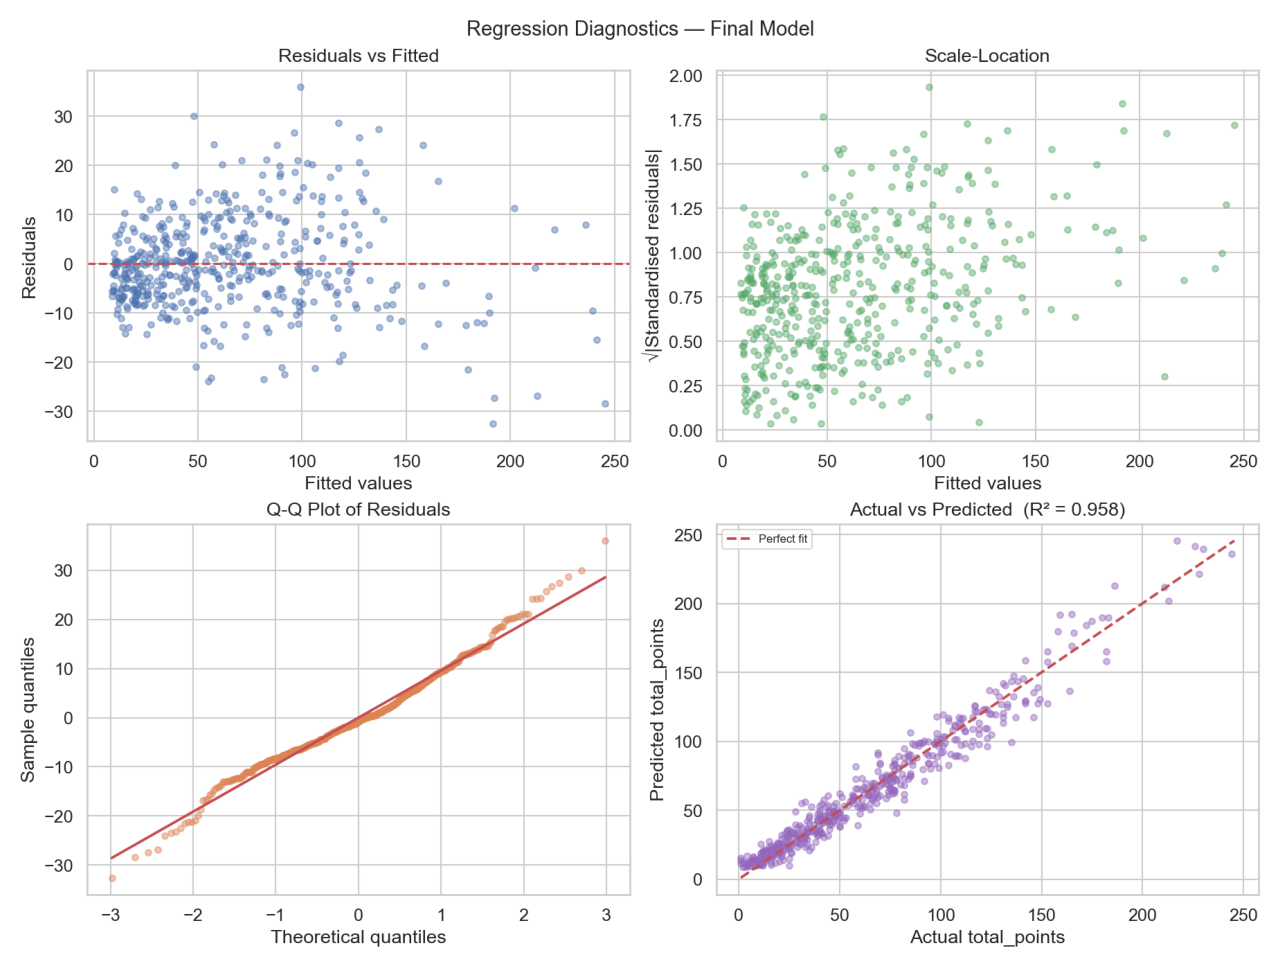

In [15]:
# Diagnostic plots
fig_path = plot_regression_diagnostics(final_model, df, selected_features)
img = mpimg.imread(fig_path)
fig, ax = plt.subplots(figsize=(12, 9))
ax.imshow(img); ax.axis('off')
plt.tight_layout()
plt.show()

**Final model interpretation:**
- Selected features: `goals`, `assists`, `influence`, `creativity`, `yellow_cards`, `clean_sheets`
- R² = 0.958 — still excellent, with 5 fewer variables
- All VIFs < 4 → no multicollinearity remaining
- **Goals** (+3.37 per goal) and **clean sheets** (+3.80) are the strongest positive predictors
- **Yellow cards** (−0.90) reduce points, as expected
- **Influence** captures ball involvement (passes, touches, defensive actions) independently of goals
- Residuals are approximately symmetric and well-behaved

---
## Step 8 — PCA: fit & interpret

STEP 8 — PCA RESULTS

  PC       Eigenvalue    Var %   Cumulative %
  --------------------------------------------
  PC1          3.5761   59.48%         59.48%
  PC2          0.8950   14.89%         74.37%
  PC3          0.6340   10.54%         84.91%
  PC4          0.4593    7.64%         92.55%
  PC5          0.2759    4.59%         97.14%
  PC6          0.1720    2.86%        100.00%

── Loadings (PC1 & PC2) ─────────────────────────────
                 PC1     PC2
goals         0.3894 -0.4520
assists       0.4398 -0.3387
influence     0.4434  0.1857
creativity    0.4527 -0.1709
yellow_cards  0.2986  0.7488
clean_sheets  0.4053  0.2379

Saved → /home/edgar/football_project/figures/pca_scree.png


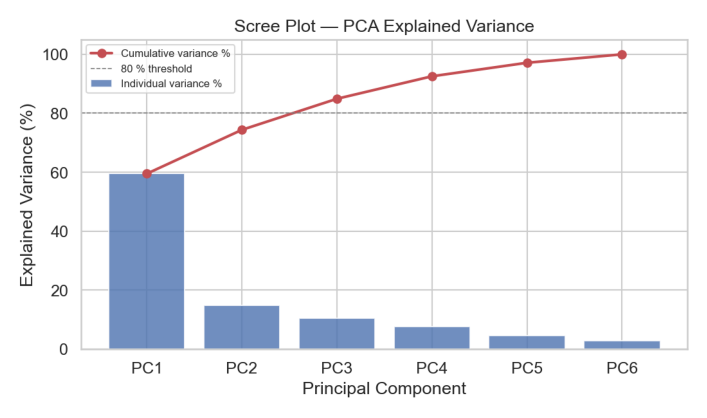

In [17]:
from src.pca import fit_pca, plot_scree, SELECTED_FEATURES

pca, X_pca, sub_df = fit_pca(df, selected_features)

fig_path = plot_scree(pca)
img = mpimg.imread(fig_path)
fig, ax = plt.subplots(figsize=(7, 4))
ax.imshow(img); ax.axis('off')
plt.tight_layout()
plt.show()

In [14]:
# Loadings table
import pandas as pd
loadings = pd.DataFrame(
    pca.components_.T,
    index=selected_features,
    columns=[f'PC{i+1}' for i in range(len(selected_features))]
).round(4)
loadings

,PC1,PC2,PC3,PC4,PC5,PC6
goals,0.3894,-0.4520,0.2311,0.6677,-0.3576,-0.1299
assists,0.4398,-0.3387,-0.4190,-0.1484,0.1069,0.6949
influence,0.4434,0.1857,0.3836,0.1399,0.7745,-0.0481
creativity,0.4527,-0.1709,-0.3907,-0.3774,0.0009,-0.6861
yellow_cards,0.2986,0.7488,-0.4094,0.3689,-0.2118,0.0405
clean_sheets,0.4053,0.2379,0.5510,-0.4838,-0.4646,0.1599


**PCA interpretation:**
- **PC1 (59.5% variance):** All positive loadings — high PC1 score = overall productive player. `creativity`, `influence`, `assists` load most strongly → PC1 captures *general performance*
- **PC2 (14.9% variance):** `yellow_cards` loads positively, `goals` and `assists` negatively → PC2 separates *disciplined, goal-scoring players* from *aggressive players who don't score much*
- The first 2 PCs together explain **74.4%** of total variance; first 3 PCs explain **84.9%**

---
## Step 9 — Correlation circle

Saved → /home/edgar/football_project/figures/correlation_circle.png


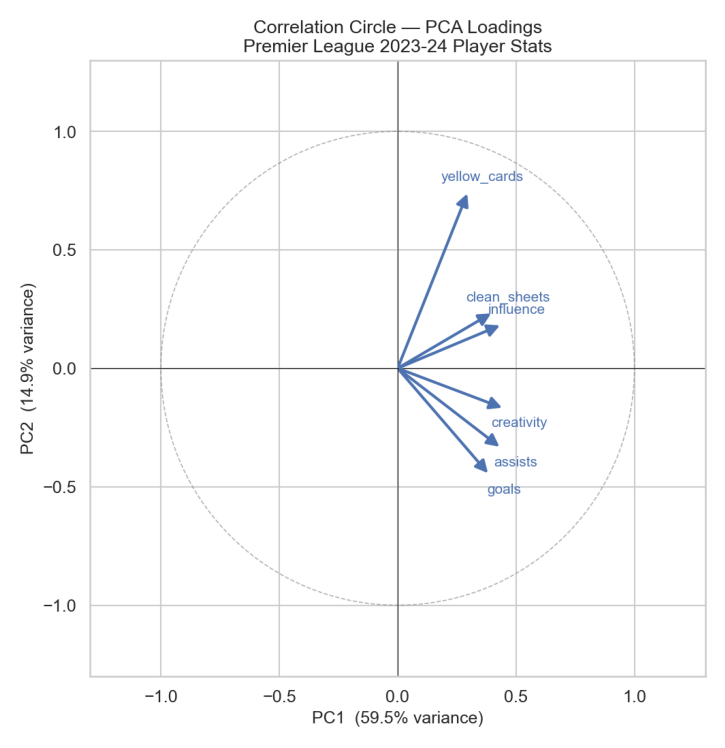

In [15]:
from src.pca import plot_correlation_circle

fig_path = plot_correlation_circle(pca, selected_features)
img = mpimg.imread(fig_path)
fig, ax = plt.subplots(figsize=(7, 7))
ax.imshow(img); ax.axis('off')
plt.tight_layout()
plt.show()

**Correlation circle interpretation:**
- `goals`, `assists`, `creativity` point in the same direction → strongly correlated, all contribute to PC1
- `clean_sheets` and `influence` point toward the same quadrant → defenders with high involvement
- `yellow_cards` points in a different direction from `goals`/`assists` → less correlated with scoring

---
## Step 10 — PCA projection + Bonus (coloured by position)

Saved → /home/edgar/football_project/figures/pca_projection.png


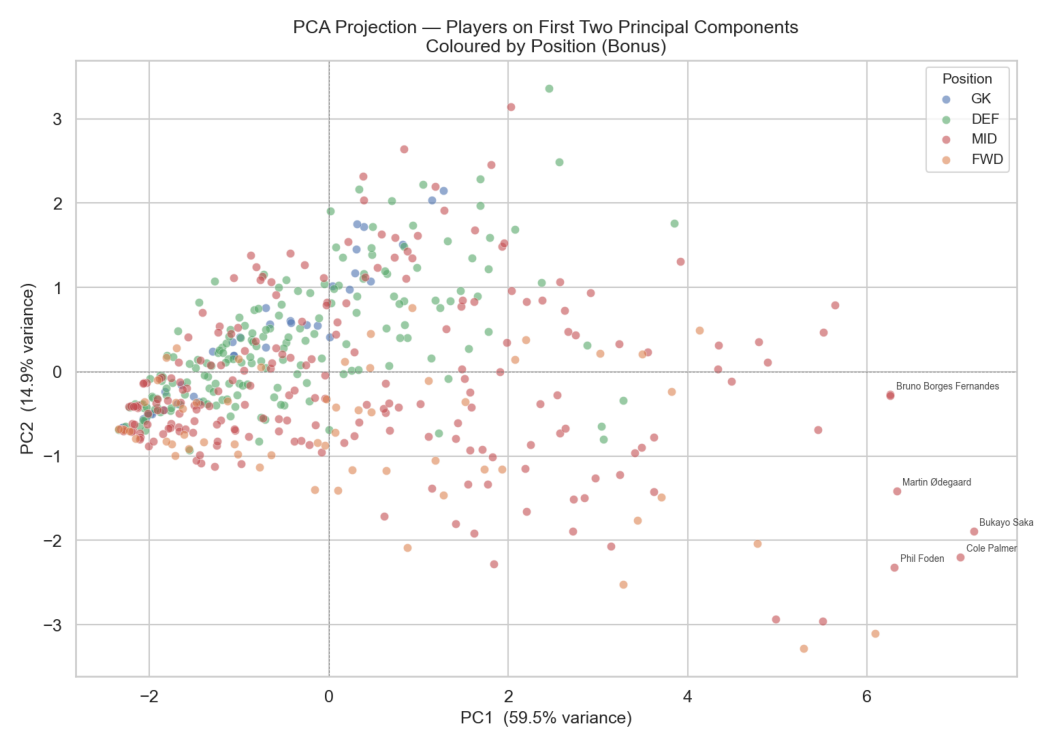

In [16]:
from src.pca import plot_pca_projection

fig_path = plot_pca_projection(X_pca, sub_df, pca)
img = mpimg.imread(fig_path)
fig, ax = plt.subplots(figsize=(10, 7))
ax.imshow(img); ax.axis('off')
plt.tight_layout()
plt.show()

**Projection interpretation (Bonus):**
- **Forwards (orange)** cluster on the right (high PC1) → high goals, assists, creativity
- **Goalkeepers (blue)** cluster separately — low on PC1 (don't score) but moderate on PC2 (clean sheets drive their value)
- **Midfielders (red)** spread across PC1 — attack-oriented mids (right) vs. defensive mids (left)
- **Defenders (green)** concentrate in the lower-left — fewer goals, more clean sheets
- The PCA projection **naturally recovers player positions** from performance statistics alone

---
## Summary

| Step | Result |
|---|---|
| Dataset | 487 PL 2023-24 players, 11 numeric variables |
| Normality | No variable is Gaussian (right-skewed distributions) |
| Response | `total_points` — well-defined, interpretable |
| Full model | R²=0.966, severe multicollinearity (VIF up to 78,000) |
| Selected model | 6 variables, R²=0.958, all VIF < 4 |
| PCA | PC1 (59.5%) = overall performance; PC2 (14.9%) = goals vs aggression |
| Bonus | PCA projection recovers player positions without using position labels |